**Initialize**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ['time', 'long', 'x', 'y', 'z']
r_kam = pd.read_csv('KAMOOALEWA.aei', sep='\s+', skiprows=4, names=cols)
r_ear = pd.read_csv('EARTHMOO.aei', sep='\s+', skiprows=4, names=cols)

**ICRF**

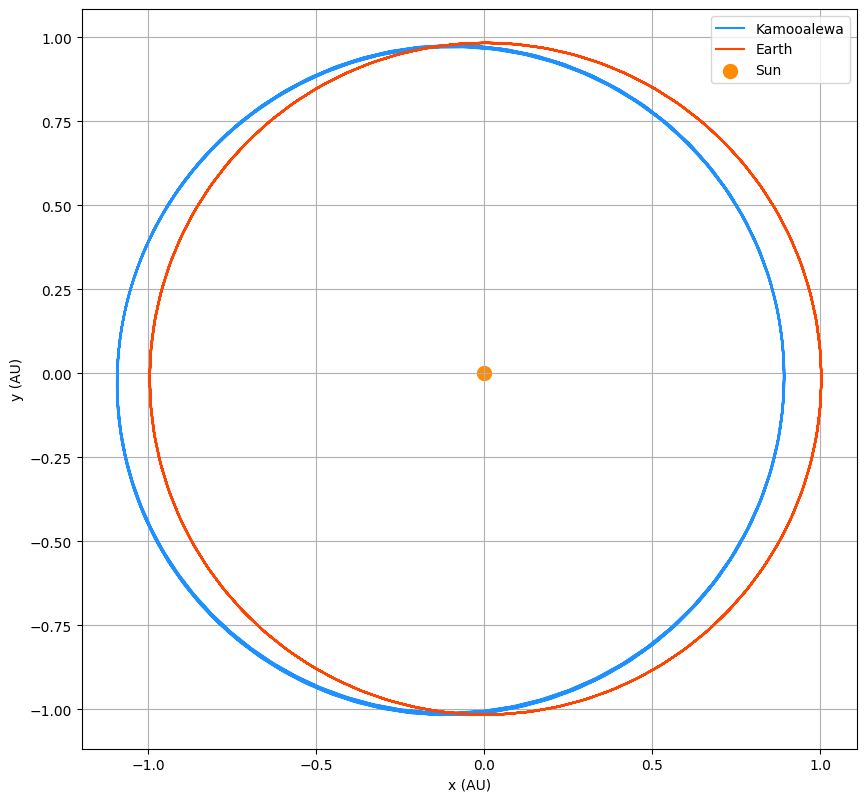

In [18]:
plt.figure(figsize=(10, 10))

plt.plot(r_kam['x'], r_kam['y'], label='Kamooalewa', color='dodgerblue')
plt.plot(r_ear['x'], r_ear['y'], label='Earth', color='orangered')
plt.scatter([0], [0], color='darkorange', s=100, label='Sun')

plt.gca().set_aspect('equal')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.legend()
plt.grid(True)
plt.show()

**Earth-centric coordinates**

In [19]:
theta_ear = np.arctan2(r_ear['y'], r_ear['x'])

kam_x_rot = r_kam['x'] * np.cos(theta_ear) + r_kam['y'] * np.sin(theta_ear)
kam_y_rot = -r_kam['x'] * np.sin(theta_ear) + r_kam['y'] * np.cos(theta_ear)

ear_x_rot = r_ear['x'] * np.cos(theta_ear) + r_ear['y'] * np.sin(theta_ear)
ear_y_rot = np.zeros_like(ear_x_rot)

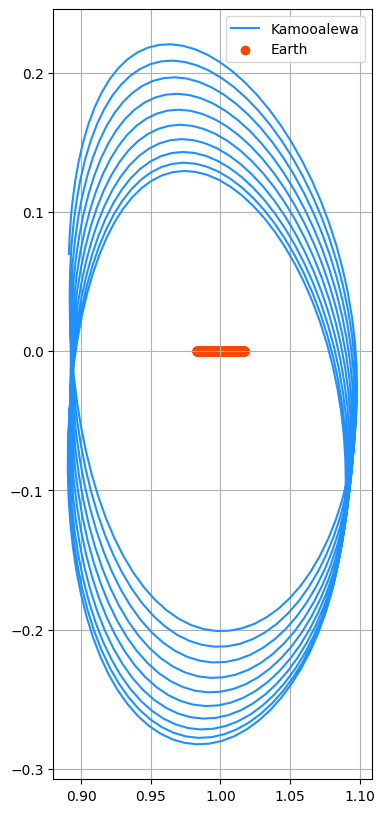

In [ ]:
plt.figure(figsize=(10, 10))

plt.plot(kam_x_rot, kam_y_rot, label='Kamooalewa', color='dodgerblue')
plt.scatter(ear_x_rot, ear_y_rot, label='Earth', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()

**HORIZONS Data**

In [37]:
from astroquery.jplhorizons import Horizons
import numpy as np

start_jd = 2458400.5
duration_yrs = 50
epochs = start_jd + np.arange(0, duration_yrs * 365.25, 150)

obj_kam = Horizons(id='469219', location='@sun', epochs=epochs)
vec_kam = obj_kam.vectors()

obj_ear = Horizons(id='3', location='@sun', epochs=epochs)
vec_ear = obj_ear.vectors()

k_real_x, k_real_y = np.array(vec_kam['x']), np.array(vec_kam['y'])
e_real_x, e_real_y = np.array(vec_ear['x']), np.array(vec_ear['y'])

theta_real = np.arctan2(e_real_y, e_real_x)

k_real_x_rot = k_real_x * np.cos(theta_real) + k_real_y * np.sin(theta_real)
k_real_y_rot = -k_real_x * np.sin(theta_real) + k_real_y * np.cos(theta_real)

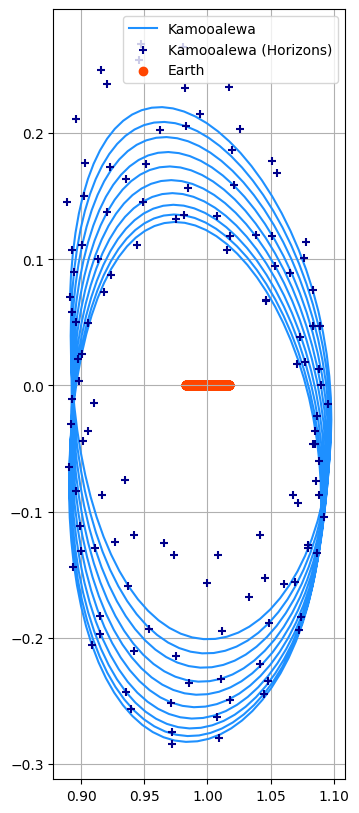

In [38]:
plt.figure(figsize=(10, 10))

plt.plot(kam_x_rot, kam_y_rot, label='Kamooalewa', color='dodgerblue')
plt.scatter(k_real_x_rot, k_real_y_rot, label='Kamooalewa (Horizons)', color='darkblue', marker='+', s=30, zorder=5)
plt.scatter(ear_x_rot, ear_y_rot, label='Earth', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()